The output of snlc_sim.exe are ".fits" files. This notebook aims to get photometry data from snlc_sim results and merge different simulation results to one csv file.

In [1]:
import pandas as pd
import numpy as np
import os
from pprint import pprint
from astropy.io import fits
import matplotlib.pyplot as plt

SIM_PATH = "/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/"

In [39]:
injections = pd.read_csv("/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns/injections_final.csv", index_col='simulation_id')
sim_ids = injections.index
print("Total number of injections:", len(sim_ids))

Total number of injections: 1822


In [3]:
sim_dirs = os.listdir(SIM_PATH)
covered_sim_ids = [int(d.split('_')[-1]) for d in sim_dirs if d.startswith('LSST_')]
print("Number of injections covered in SNANA SIM output:", len(covered_sim_ids))

Number of injections covered in SNANA SIM output: 1693


In [10]:
covered_sim_ids = sorted(covered_sim_ids)
sample_num = {}
valid_sim_ids = []
NLIBID = {}

for i, sim_id in enumerate(covered_sim_ids):
    dump_file = os.path.join(SIM_PATH, f"LSST_KN_{sim_id}", f"LSST_KN_{sim_id}.DUMP")
    readme_file = os.path.join(SIM_PATH, f"LSST_KN_{sim_id}", f"LSST_KN_{sim_id}.README")
    with open(dump_file, 'r') as f:
        lines = f.readlines()
        if len(lines)==0:
            continue
        sample_num[sim_id] = len(lines) - 8  # Exclude header line
        if sample_num[sim_id]>0:
            valid_sim_ids.append(sim_id)
        # print(f"Simulation {sim_id} has {sample_num[i]} samples.")
    with open(readme_file, "r") as f:
        line = f.readlines()[18]
        NLIBID[sim_id]=int(line.split()[1])

print("Successfully run snlc_sim:", len(sample_num))
print("Total number of light curves in SNANA SIM output:", sum(sample_num.values()))
print("Valid simulation IDs with LCs:", valid_sim_ids)
print("NLIBID for all simulations:", NLIBID)
print("Total number of LIBIDs:", sum(NLIBID.values()))
print("Total numbers of valid simulations:", len(valid_sim_ids))

Successfully run snlc_sim: 1693
Total number of light curves in SNANA SIM output: 405724
Valid simulation IDs with LCs: [16, 22, 26, 42, 47, 49, 61, 62, 65, 75, 81, 88, 101, 111, 114, 116, 117, 118, 119, 131, 135, 136, 152, 153, 157, 165, 169, 174, 180, 184, 200, 204, 207, 225, 234, 238, 241, 242, 243, 244, 251, 253, 254, 258, 270, 287, 294, 302, 303, 304, 307, 321, 325, 326, 328, 331, 334, 336, 338, 352, 354, 364, 369, 370, 378, 382, 394, 402, 406, 414, 447, 448, 460, 472, 483, 484, 491, 493, 503, 519, 531, 532, 545, 547, 548, 554, 558, 564, 569, 573, 576, 585, 588, 618, 629, 637, 638, 640, 653, 654, 663, 666, 675, 682, 684, 685, 686, 703, 708, 709, 718, 719, 720, 729, 730, 733, 734, 738, 742, 750, 758, 764, 767, 771, 772, 780, 788, 789, 800, 801, 802, 803, 811, 817, 820, 830, 833, 837, 841, 842, 851, 852, 872, 876, 877, 885, 893, 905, 914, 916, 927, 931, 950, 952, 955, 957, 958, 967, 968, 970, 972, 975, 977, 981, 985, 989, 992, 994, 1013, 1016, 1020, 1022, 1023, 1029, 1036, 1043, 104

In [ ]:
# calculate fraction
print("Total number of LIBIDs:", sum(NLIBID.values()))
print("Total number of light curves in SNANA SIM output:", sum(sample_num.values()))

frac = sum(sample_num.values())/sum(NLIBID.values())
print("Fraction: Detected lightcurves / Simulated lightcurves:", frac)

Total number of LIBIDs: 14099864
Total number of light curves in SNANA SIM output: 405724
Fraction of detected lightcurves: 0.028775029319431735


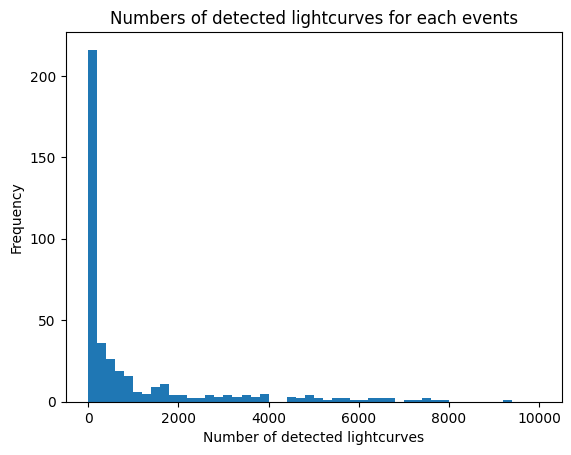

In [14]:
plt.hist(sample_num.values(), bins=50, range=[1,10000])
plt.title("Numbers of detected lightcurves for each events")
plt.xlabel("Number of detected lightcurves")
plt.ylabel("Frequency")
plt.show()

## Analyse distribution of simulations with results

In [47]:
valid_inj = injections[np.isin(injections.index, valid_sim_ids)]
valid_inj['NLIBID'] = np.ones(len(valid_inj),dtype=int)
valid_inj['NDET_LC'] = np.ones(len(valid_inj),dtype=int)
for sim_id in valid_inj.index:
    valid_inj.loc[sim_id,'NLIBID'] = NLIBID[sim_id]
    valid_inj.loc[sim_id,'NDET_LC'] = sample_num[sim_id]
valid_inj

/tmp/ipykernel_3379336/4233683910.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_inj['NLIBID'] = np.ones(len(valid_inj),dtype=int)
/tmp/ipykernel_3379336/4233683910.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_inj['NDET_LC'] = np.ones(len(valid_inj),dtype=int)


,mjd_time,gps_time,longitude,latitude,ra,dec,inclination,distance,mass1,mass2,...,compactness2,mej_dyn,mej_wind,mej_total,phi,costheta,distmean,diststd,NLIBID,NDET_LC
simulation_id,,,,,,,,,,,,,,,,,,,,,
16,63197.6935,1.637599e+09,5.470332,0.136340,313.426919,7.811696,2.143329,381.31009,1.485862,1.411135,...,0.17485,0.002886,0.023251,0.026138,37.288056,0.541763,646.749849,225.624429,3546,5
22,61668.5650,1.505482e+09,0.373078,-0.435035,21.375821,-24.925671,2.883460,216.89843,1.356997,1.251854,...,0.15428,0.002305,0.063343,0.065648,42.377880,0.966868,196.172658,40.278797,7118,5096
26,62098.6401,1.542641e+09,3.974584,0.496561,227.726883,28.450847,0.229814,287.12256,1.461213,1.484442,...,0.18457,0.002955,0.020643,0.023598,32.458937,0.973709,471.566567,215.924137,3725,2
42,62285.2002,1.558760e+09,2.905688,1.270784,166.483653,72.810571,1.970406,337.09581,1.490620,1.432238,...,0.17762,0.002928,0.055248,0.058176,60.035095,0.389059,620.953390,264.967351,9690,192
47,63324.4883,1.648554e+09,2.971165,-0.854202,170.235220,-48.942144,0.472468,531.54896,1.483816,1.589060,...,0.19887,0.003441,0.031049,0.034489,38.094391,0.890448,515.547466,172.749053,11031,888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2289,62797.7510,1.603044e+09,2.880703,0.802580,165.052107,45.984446,2.183413,663.83052,1.608796,1.549368,...,0.19337,0.003614,0.020183,0.023797,25.152672,0.575011,794.956390,250.356261,3917,10
2291,61744.4267,1.512037e+09,0.513252,-1.277873,29.407177,-73.216724,2.154036,151.96069,1.171929,1.401797,...,0.17362,0.002701,0.025851,0.028552,70.867308,0.550731,217.157042,55.343842,9951,1187
2297,61558.0001,1.495930e+09,1.866434,-0.526386,106.938814,-30.159677,1.046183,418.41066,1.340292,1.600109,...,0.20041,0.003828,0.038988,0.042815,45.154976,0.500878,722.005345,253.606728,13040,2


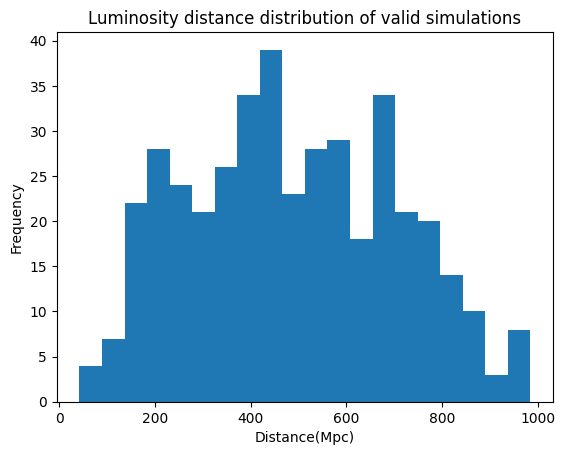

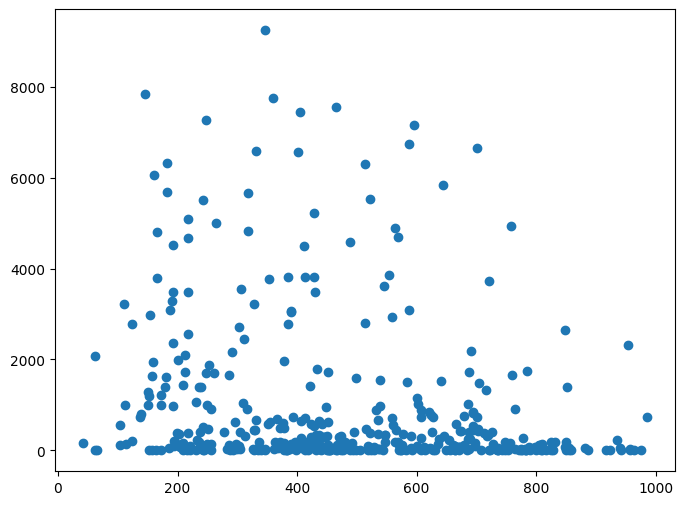

In [48]:
valid_dist = valid_inj['distance']
plt.hist(valid_dist, bins=20)
plt.xlabel("Distance(Mpc)")
plt.ylabel("Frequency")
plt.title("Luminosity distance distribution of valid simulations")
plt.figure(figsize=(8,6))
plt.scatter(valid_dist, valid_inj['NDET_LC'])

Numbers of light curves: 400186


Text(0.5, 1.0, 'Redshift distribution of detected light curves')

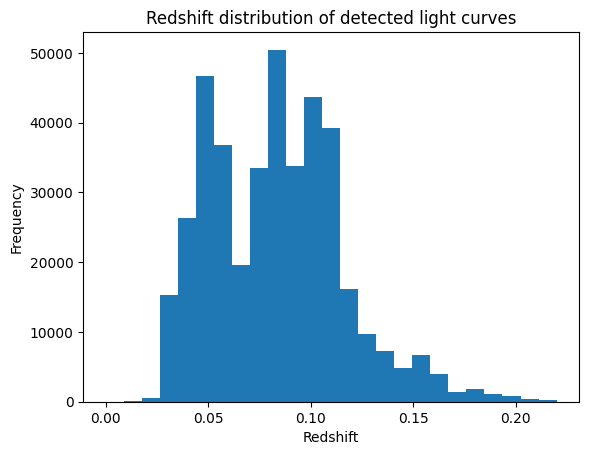

In [75]:
# get redshift for each lightcurve
redshift_lcs = np.empty(0)
for id in valid_sim_ids:
    head_file = os.path.join(SIM_PATH, f"LSST_KN_{id}", f"LSST_KN_{id}_HEAD.FITS")
    try:
        head_hdul = fits.open(head_file)
        head_data = head_hdul[1].data
        redshift_lcs = np.concatenate([redshift_lcs, head_data['REDSHIFT_FINAL']])
    except:
        continue
print("Numbers of light curves:",len(redshift_lcs))
plt.hist(redshift_lcs, range=(0.0,0.22), bins=25)
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.title("Redshift distribution of detected light curves")

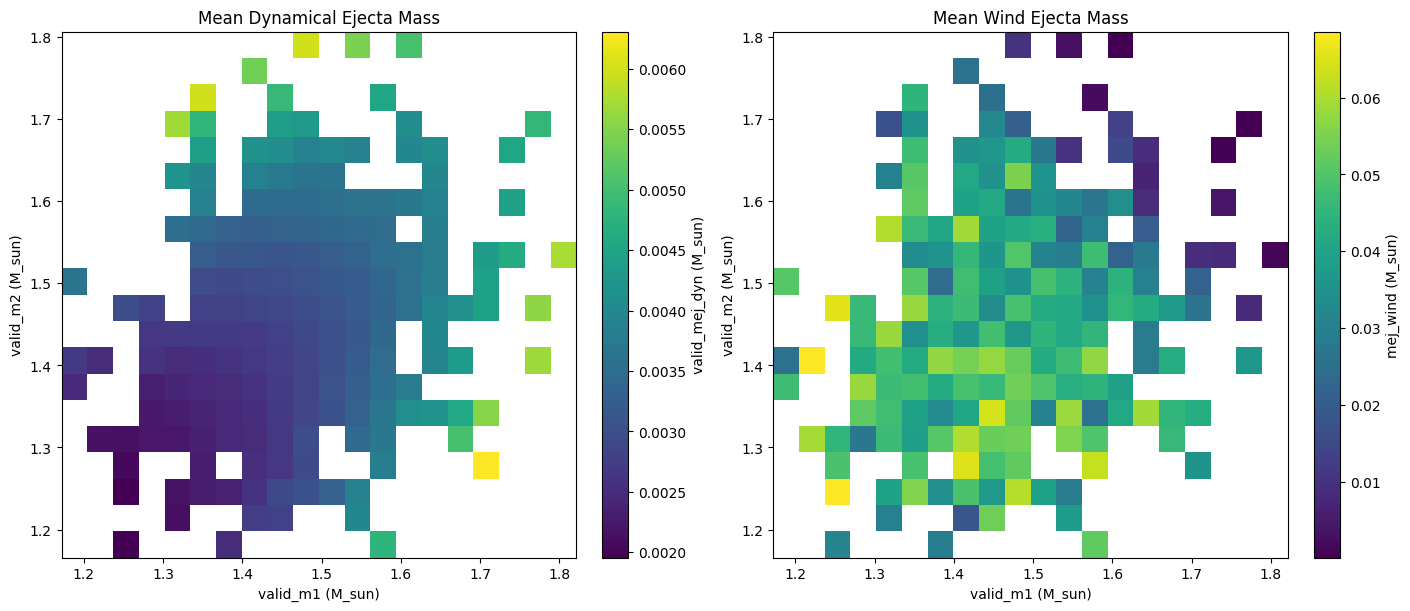

In [13]:
valid_mej_dyn = valid_inj['mej_dyn']
valid_mej_wind = valid_inj['mej_wind']
valid_m1 = valid_inj['mass1']
valid_m2 = valid_inj['mass2']

# Heatmaps of ejecta masses vs (mass1, mass2)
bins = 20

# 2D mean for dynamical ejecta
H_sum_dyn, xedges, yedges = np.histogram2d(valid_m1, valid_m2, bins=bins, weights=valid_mej_dyn)
H_count, _, _ = np.histogram2d(valid_m1, valid_m2, bins=[xedges, yedges])
H_mean_dyn = H_sum_dyn / np.where(H_count == 0, np.nan, H_count)

# 2D mean for wind ejecta
H_sum_wind, _, _ = np.histogram2d(valid_m1, valid_m2, bins=[xedges, yedges], weights=valid_mej_wind)
H_mean_wind = H_sum_wind / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean_dyn.T, cmap='viridis', shading='auto')
axs[0].set_xlabel('valid_m1 (M_sun)')
axs[0].set_ylabel('valid_m2 (M_sun)')
axs[0].set_title('Mean Dynamical Ejecta Mass')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('valid_mej_dyn (M_sun)')

im1 = axs[1].pcolormesh(xedges, yedges, H_mean_wind.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('valid_m1 (M_sun)')
axs[1].set_ylabel('valid_m2 (M_sun)')
axs[1].set_title('Mean Wind Ejecta Mass')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('mej_wind (M_sun)')

plt.show()

Text(0.5, 1.0, 'Ejecta mass distribution')

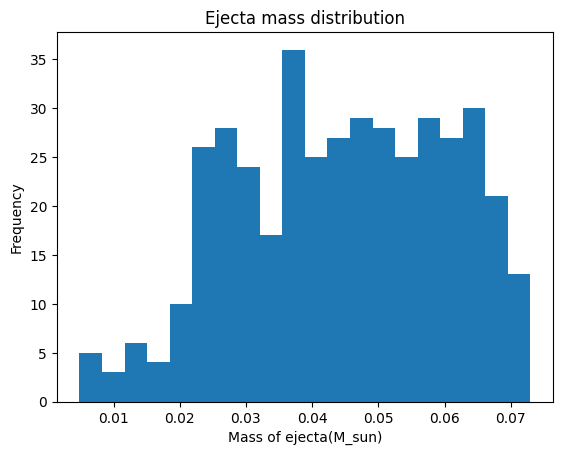

In [14]:
valid_mej_total = valid_inj['mej_total']
plt.hist(valid_mej_total,bins=20)
plt.xlabel("Mass of ejecta(M_sun)")
plt.ylabel("Frequency")
plt.title("Ejecta mass distribution")

Text(0.5, 1.0, 'Observing Angle distribution')

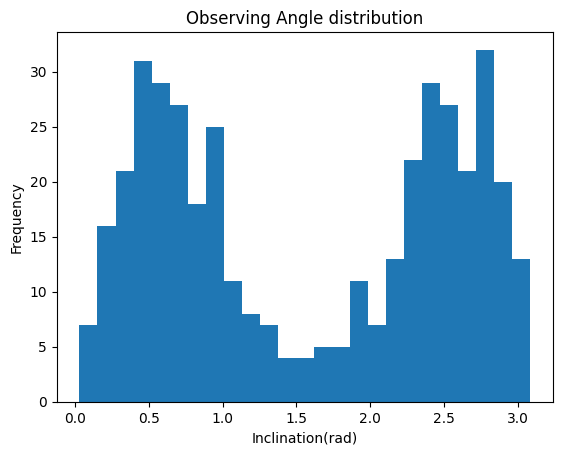

In [77]:
valid_obs_angle = valid_inj['inclination']
plt.hist(valid_obs_angle, bins=25)
plt.xlabel("Inclination(rad)")
plt.ylabel("Frequency")
plt.title("Observing Angle distribution")

In [18]:
sim_id = 26
phot_file = os.path.join(SIM_PATH, f"LSST_KN_{sim_id}", f"LSST_KN_{sim_id}_PHOT.FITS")
head_file = os.path.join(SIM_PATH, f"LSST_KN_{sim_id}", f"LSST_KN_{sim_id}_HEAD.FITS")
# 打开PHOT.fits文件
phot_hdul = fits.open(phot_file)
phot_data = phot_hdul[1].data

# 打开HEAD.fits文件，获取每个源的光变曲线索引分界
head_hdul = fits.open(head_file)
head_data = head_hdul[1].data
start_indices = head_data['PTROBS_MIN']
end_indices = head_data['PTROBS_MAX']

mjd_explode = injections['mjd_time'][np.where(injections['simulation_id']==sim_id)[0]].values
mjd_explode

array([62098.6401])

In [20]:
def convert_fluxcal_to_mag(flux, err):
    """Convert fluxcal to magnitude and add magnitude error

    Args:
        df (pd.DataFrame): DataFrame with columns "FLUXCAL" and "FLUXCALERR"
    Returns:
        pd.DataFrame: DataFrame with added "magnitude" and "magnitude error"
    """
    # Convert fluxcal to magnitude
    flux[flux <= 0] = np.nan

    # Compute magnitude; where flux was <= 0, magnitude will be NaN
    mag = -2.5 * np.log10(flux) + 27.5
    magerr = 2.5 / np.log(10) * err / flux
    return mag, magerr

In [ ]:
for j, id in enumerate(valid_sim_ids):
    print("Simulation id:", id)
    mjd_explode = injections['mjd_time'][np.where(injections['simulation_id']==id)[0]].values
    if j>4:
        break
    phot_file = os.path.join(SIM_PATH, f"LSST_KN_{id}", f"LSST_KN_{id}_PHOT.FITS")
    head_file = os.path.join(SIM_PATH, f"LSST_KN_{id}", f"LSST_KN_{id}_HEAD.FITS")
    # 打开PHOT.fits文件
    phot_hdul = fits.open(phot_file)
    phot_data = phot_hdul[1].data

    # 打开HEAD.fits文件，获取每个源的光变曲线索引分界
    head_hdul = fits.open(head_file)
    head_data = head_hdul[1].data
    start_indices = head_data['PTROBS_MIN']
    end_indices = head_data['PTROBS_MAX']

    bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-y']
    for i, (start, end) in enumerate(zip(start_indices, end_indices)):
        if i > 1:
            break
        plt.figure(figsize=(8,6))
        peakmjd = head_data['SIM_PEAKMJD'][i]
        print(f'Plotting source {i+1},Merger MJD: {mjd_explode[0]} PEAKMJD: {peakmjd}, Index range: {start}-{end}')
        plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
        plt.axvline(x=mjd_explode[0], color='r', linestyle='--', label="Merger MJD")
        source_data = phot_data[start-1:end]  # FITS索引通常从1开始
        mjd = source_data['MJD']
        flux = source_data['FLUXCAL']
        fluxerr = source_data['FLUXCALERR']
        mag, magerr = convert_fluxcal_to_mag(flux=flux.copy(), err=fluxerr)
        for band in bands:
            band_mask = source_data['BAND'] == band
            # plt.errorbar(mjd[band_mask], mag[band_mask], yerr=magerr[band_mask], fmt='o', label=band)
            plt.errorbar(mjd[band_mask], flux[band_mask], yerr=fluxerr[band_mask], fmt='o', label=band)
            # plt.errorbar(mjd, flux, yerr=err, fmt='o', label=f'Source {i+1}')
            plt.xlabel('MJD', fontsize=18)
            plt.xticks(fontsize=14)
            plt.ylabel('FLUXCAL', fontsize=18)
            plt.yticks(fontsize=14)
            plt.title('Light Curves from SNANA simulation', fontsize=18)
            plt.legend(fontsize=12)

Simulation id: 16
Plotting source 1,Merger MJD: 63197.6935 PEAKMJD: 63197.6953125, Index range: 1-98
Plotting source 2,Merger MJD: 63197.6935 PEAKMJD: 63197.6953125, Index range: 100-186
Plotting source 3,Merger MJD: 63197.6935 PEAKMJD: 63197.6953125, Index range: 188-260
Plotting source 4,Merger MJD: 63197.6935 PEAKMJD: 63197.6953125, Index range: 262-362
Plotting source 5,Merger MJD: 63197.6935 PEAKMJD: 63197.6953125, Index range: 364-454
Simulation id: 22
Plotting source 1,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 1-62
Plotting source 2,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 64-110
Plotting source 3,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 112-177
Plotting source 4,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 179-257
Plotting source 5,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 259-342
Plotting source 6,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 344-442
Plotting source 7,Merger 

/tmp/ipykernel_1207977/1737453971.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,6))


Plotting source 16,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 1342-1441
Plotting source 17,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 1443-1544
Plotting source 18,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 1546-1654
Plotting source 19,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 1656-1746
Plotting source 20,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 1748-1840
Plotting source 21,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 1842-1934
Plotting source 22,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 1936-2026
Plotting source 23,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 2028-2108
Plotting source 24,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 2110-2193
Plotting source 25,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 2195-2275
Plotting source 26,Merger MJD: 61668.565 PEAKMJD: 61668.56640625, Index range: 2277-2373
Plotting source 27,Me

KeyboardInterrupt: 